In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

In [4]:
df=pd.read_excel("/content/drive/MyDrive/DA/ApexPlanet_DataAnalytics_Dataset.xlsx")

In [5]:
df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales
0,ORD100002,2025-02-25,CUST5529,Customer_227,30.0,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39
1,ORD100003,2025-10-14,CUST3127,Customer_182,63.0,Male,Bengaluru,Book,Education,5,27906.16,139530.80
2,ORD100004,2025-05-13,CUST8887,Customer_487,62.0,Female,Bengaluru,Book,Education,8,37491.06,299928.48
3,ORD100005,2025-12-02,CUST2515,Customer_470,65.0,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24
4,ORD100006,2025-11-20,CUST4796,Customer_380,44.0,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90


### Task 1: Data Understanding and Initial Exploration

First, let's get a concise summary of the DataFrame, including the data types of each column and the number of non-null values. Then, we will look at descriptive statistics for numerical columns.

In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       1000 non-null   object 
 1   Order_Date     1000 non-null   object 
 2   Customer_ID    1000 non-null   object 
 3   Customer_Name  1000 non-null   object 
 4   Age            980 non-null    float64
 5   Gender         1000 non-null   object 
 6   City           987 non-null    object 
 7   Product        1000 non-null   object 
 8   Category       1000 non-null   object 
 9   Quantity       1000 non-null   int64  
 10  Unit_Price     1000 non-null   float64
 11  Total_Sales    1000 non-null   float64
dtypes: float64(3), int64(1), object(8)
memory usage: 93.9+ KB
None


In [7]:
display(df.describe())

,Age,Quantity,Unit_Price,Total_Sales
count,980.000000,1000.000000,1000.000000,1000.000000
mean,41.360204,5.435000,25486.783410,139399.439650
std,13.822597,2.838632,14179.402361,114100.051546
min,18.000000,1.000000,145.780000,437.340000
25%,30.000000,3.000000,13895.722500,47066.632500
50%,41.000000,5.000000,25398.740000,108594.025000
75%,54.000000,8.000000,37512.382500,203722.882500
max,65.000000,10.000000,49997.530000,493677.500000


### Missing Value Analysis

Let's calculate the percentage of missing values for each column to understand the extent of the data incompleteness.

In [8]:
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

missing_info = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percentage
})

display(missing_info[missing_info['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False))

,Missing Count,Missing Percentage
Age,20,2.0
City,13,1.3


### Handling Missing Values

Given the relatively small percentage of missing values in 'Age' and 'City', we will impute them. For 'Age', we'll use the median, and for 'City', we'll use the mode.

In [9]:
# Impute missing 'Age' values with the median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Impute missing 'City' values with the mode
df['City'] = df['City'].fillna(df['City'].mode()[0])

# Verify that there are no more missing values
print('Missing values after imputation:')
display(df.isnull().sum())

Missing values after imputation:


,0
Order_ID,0
Order_Date,0
Customer_ID,0
Customer_Name,0
Age,0
Gender,0
City,0
Product,0
Category,0
Quantity,0


### Data Type Conversion

The 'Order_Date' column is currently an object type. Converting it to a datetime format will allow for time-based analysis.

In [10]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

print('Data types after conversion:')
display(df.info())

Data types after conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order_ID       1000 non-null   object        
 1   Order_Date     1000 non-null   datetime64[ns]
 2   Customer_ID    1000 non-null   object        
 3   Customer_Name  1000 non-null   object        
 4   Age            1000 non-null   float64       
 5   Gender         1000 non-null   object        
 6   City           1000 non-null   object        
 7   Product        1000 non-null   object        
 8   Category       1000 non-null   object        
 9   Quantity       1000 non-null   int64         
 10  Unit_Price     1000 non-null   float64       
 11  Total_Sales    1000 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(7)
memory usage: 93.9+ KB


None

### Duplicate Entry Handling

It's important to check for and remove any duplicate rows to ensure the integrity and accuracy of our analysis. Duplicates can skew statistics and lead to incorrect conclusions.

In [11]:
initial_rows = df.shape[0]
df.drop_duplicates(inplace=True)
final_rows = df.shape[0]

print(f"Initial number of rows: {initial_rows}")
print(f"Number of rows after removing duplicates: {final_rows}")
print(f"Number of duplicate rows removed: {initial_rows - final_rows}")

Initial number of rows: 1000
Number of rows after removing duplicates: 1000
Number of duplicate rows removed: 0


### Categorical Feature Analysis

Let's examine the unique values and their counts for key categorical columns to understand their distribution and identify any potential inconsistencies.

In [12]:
for column in ['Gender', 'City', 'Product', 'Category']:
    print(f"\nUnique values and their counts for '{column}':")
    display(df[column].value_counts())


Unique values and their counts for 'Gender':


,count
Gender,
Male,511
Female,489



Unique values and their counts for 'City':


,count
City,
Patna,148
Kolkata,133
Mumbai,131
Hyderabad,125
Delhi,125
Bengaluru,122
Gaya,117
Pune,99



Unique values and their counts for 'Product':


,count
Product,
Mobile,184
Book,178
Laptop,170
Chair,159
Shoes,156
Rice,153



Unique values and their counts for 'Category':


,count
Category,
Electronics,354
Education,178
Furniture,159
Fashion,156
Grocery,153


In [13]:
print(f"\nUnique values and their counts for 'Product':")
display(df['Product'].value_counts())

print(f"\nUnique values and their counts for 'Category':")
display(df['Category'].value_counts())


Unique values and their counts for 'Product':


,count
Product,
Mobile,184
Book,178
Laptop,170
Chair,159
Shoes,156
Rice,153



Unique values and their counts for 'Category':


,count
Category,
Electronics,354
Education,178
Furniture,159
Fashion,156
Grocery,153


### Task 2: Data Visualization and Further Exploration

Let's visualize the distribution of key categorical features and explore overall sales trends to gain deeper insights into the data.

/tmp/ipykernel_387/1554286760.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Gender', palette='viridis')


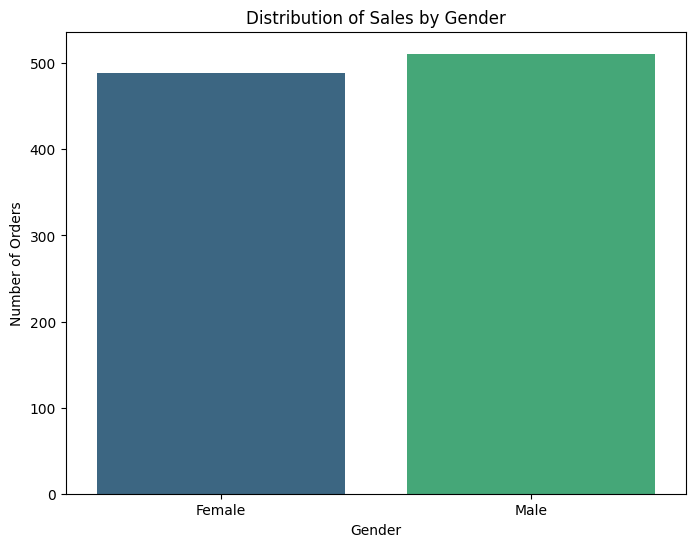

In [14]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Gender', palette='viridis')
plt.title('Distribution of Sales by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Orders')
plt.show()

/tmp/ipykernel_387/1353727843.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='City', order=df['City'].value_counts().index, palette='plasma')


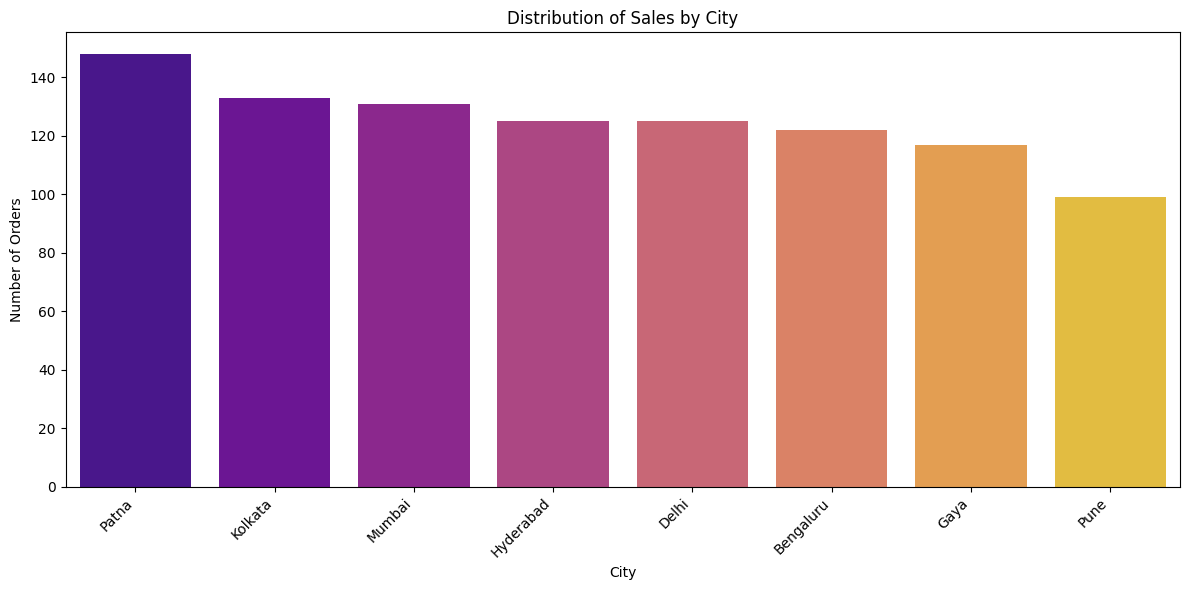

In [15]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='City', order=df['City'].value_counts().index, palette='plasma')
plt.title('Distribution of Sales by City')
plt.xlabel('City')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/tmp/ipykernel_387/1452860933.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Category', order=df['Category'].value_counts().index, palette='mako')


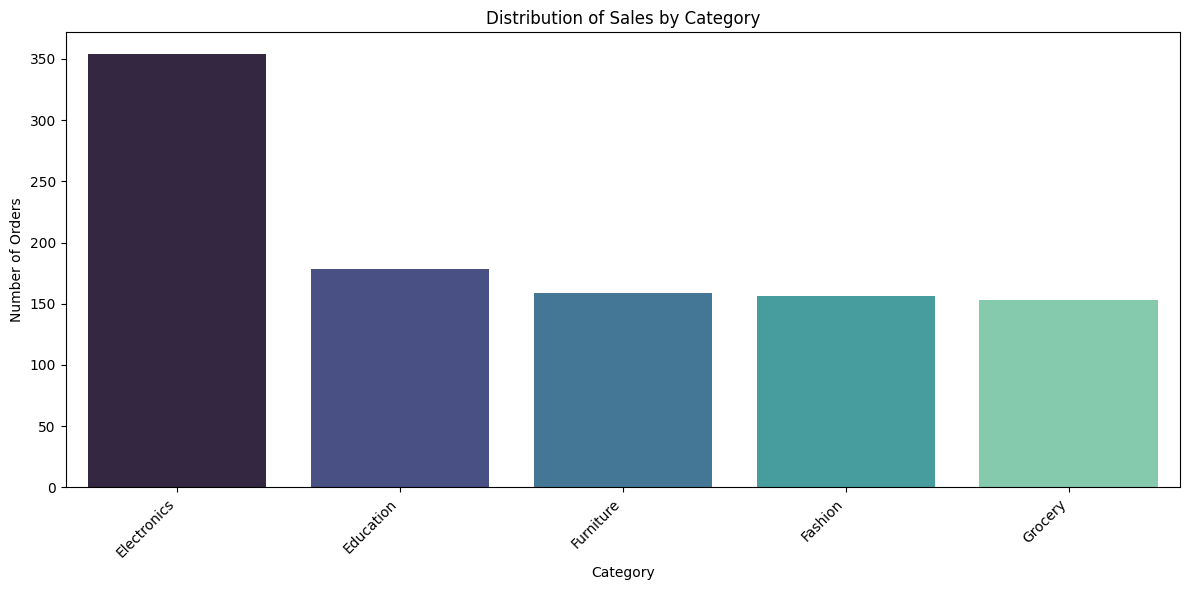

In [16]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Category', order=df['Category'].value_counts().index, palette='mako')
plt.title('Distribution of Sales by Category')
plt.xlabel('Category')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/tmp/ipykernel_387/1988395749.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Product', order=df['Product'].value_counts().index[:10], palette='rocket') # Top 10 products


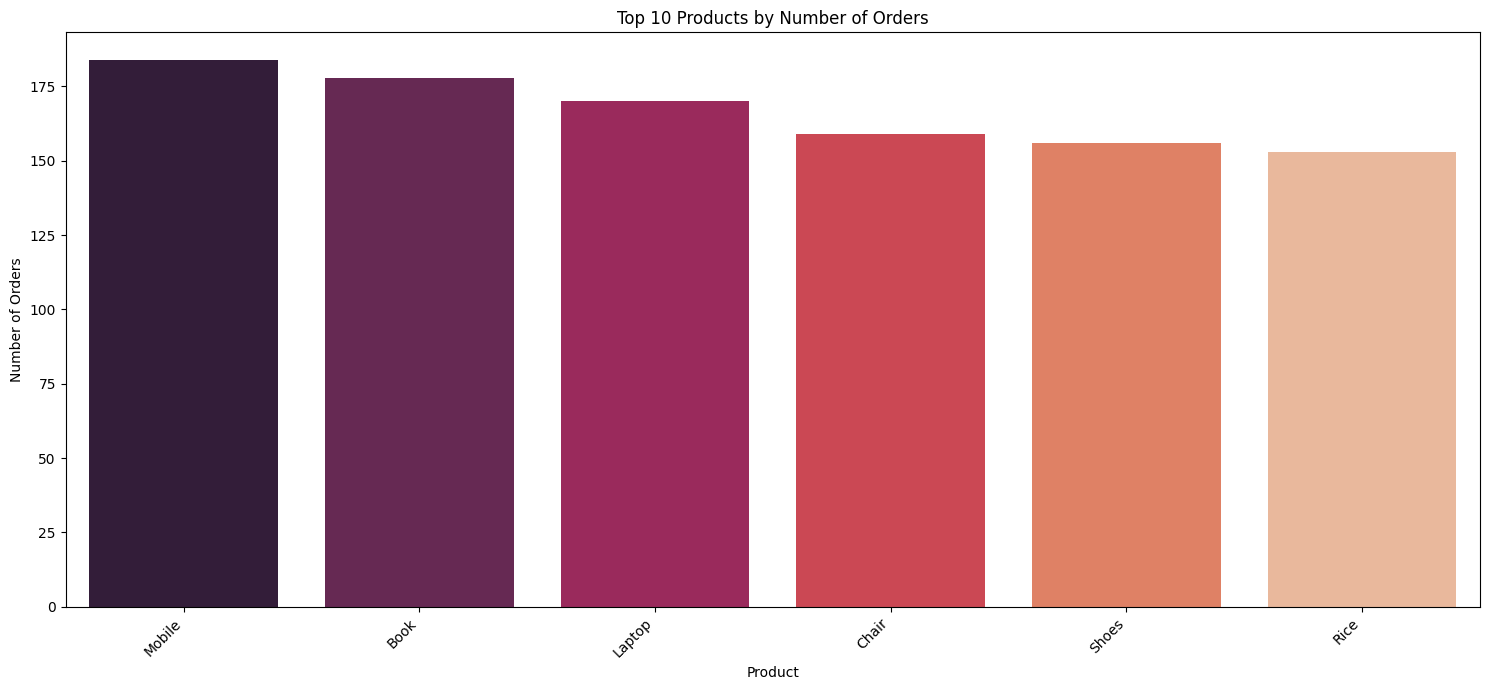

In [17]:
plt.figure(figsize=(15, 7))
sns.countplot(data=df, x='Product', order=df['Product'].value_counts().index[:10], palette='rocket') # Top 10 products
plt.title('Top 10 Products by Number of Orders')
plt.xlabel('Product')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Now, let's look at the sales trends over time.

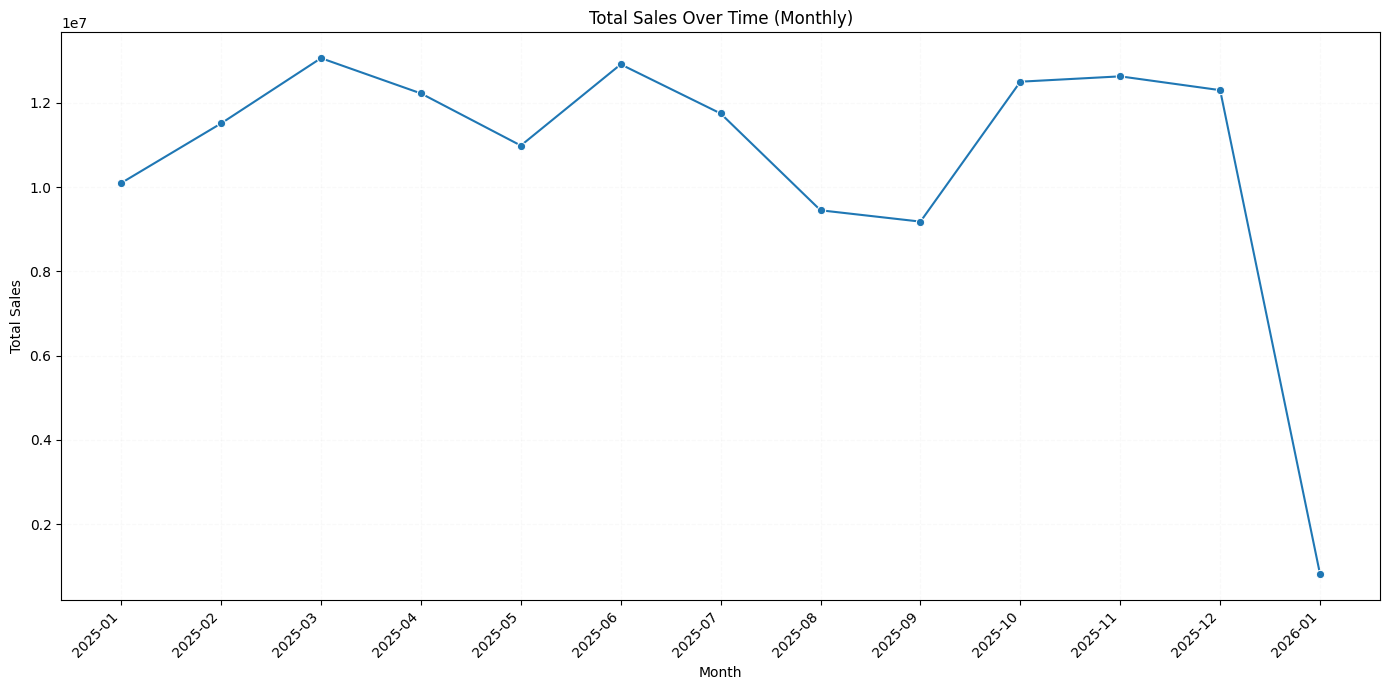

In [18]:
df['YearMonth'] = df['Order_Date'].dt.to_period('M')
monthly_sales = df.groupby('YearMonth')['Total_Sales'].sum().reset_index()
monthly_sales['YearMonth'] = monthly_sales['YearMonth'].astype(str) # Convert to string for plotting

plt.figure(figsize=(14, 7))
sns.lineplot(data=monthly_sales, x='YearMonth', y='Total_Sales', marker='o')
plt.title('Total Sales Over Time (Monthly)')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.07)
plt.tight_layout()
plt.show()

### Task 3: Sales Performance Analysis

Let's analyze sales performance across various dimensions to identify key trends and contributors to total sales.

/tmp/ipykernel_387/3088422959.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sales_by_gender, x='Gender', y='Total_Sales', palette='coolwarm')


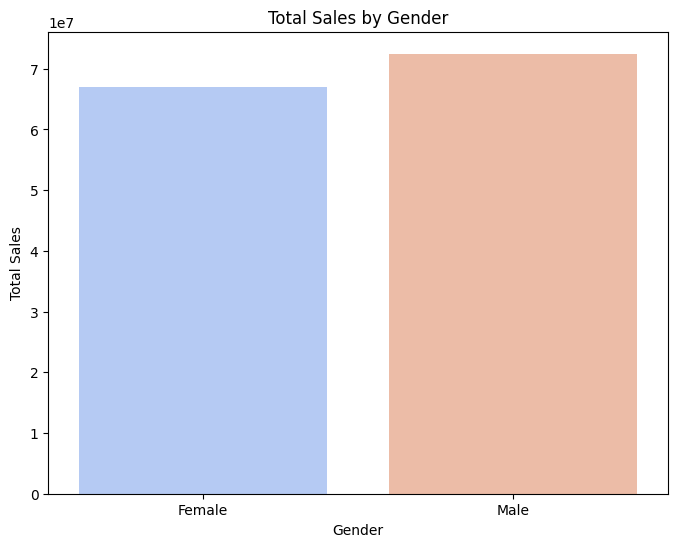

In [19]:
# Sales by Gender
sales_by_gender = df.groupby('Gender')['Total_Sales'].sum().reset_index()

plt.figure(figsize=(8, 6))
sns.barplot(data=sales_by_gender, x='Gender', y='Total_Sales', palette='coolwarm')
plt.title('Total Sales by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Sales')
plt.show()

/tmp/ipykernel_387/1747208737.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sales_by_city, x='City', y='Total_Sales', palette='magma')


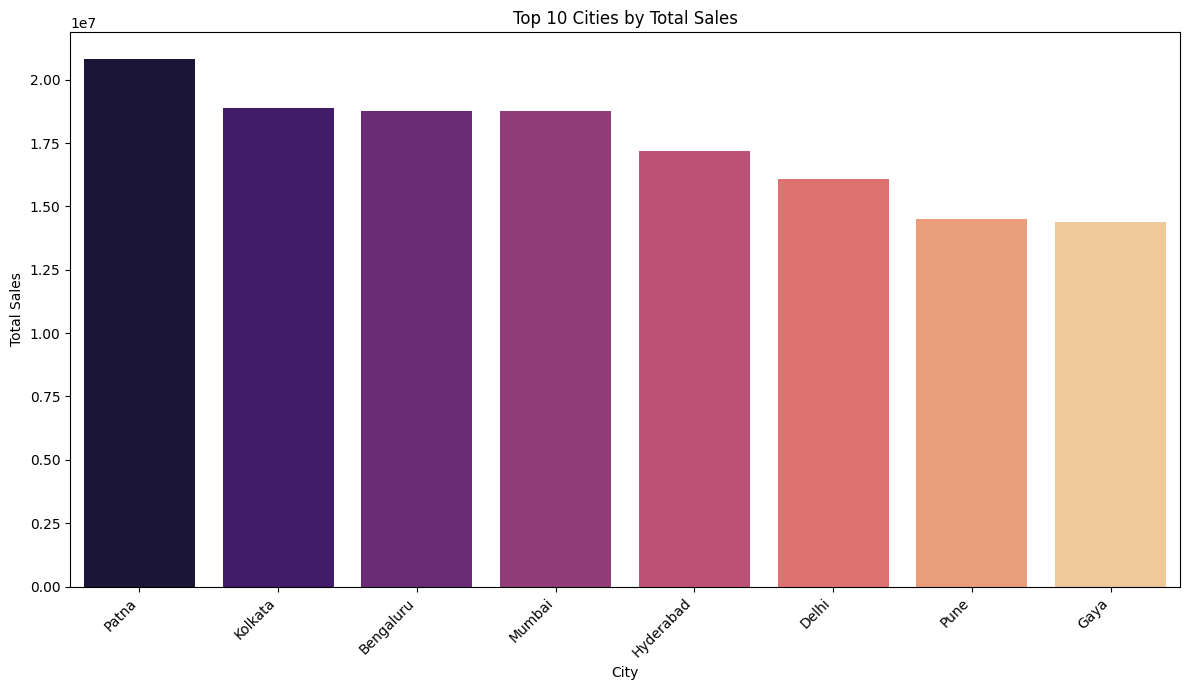

In [20]:
# Sales by City (Top 10)
sales_by_city = df.groupby('City')['Total_Sales'].sum().reset_index().sort_values(by='Total_Sales', ascending=False).head(10)

plt.figure(figsize=(12, 7))
sns.barplot(data=sales_by_city, x='City', y='Total_Sales', palette='magma')
plt.title('Top 10 Cities by Total Sales')
plt.xlabel('City')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/tmp/ipykernel_387/3307297194.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sales_by_category, x='Category', y='Total_Sales', palette='rocket')


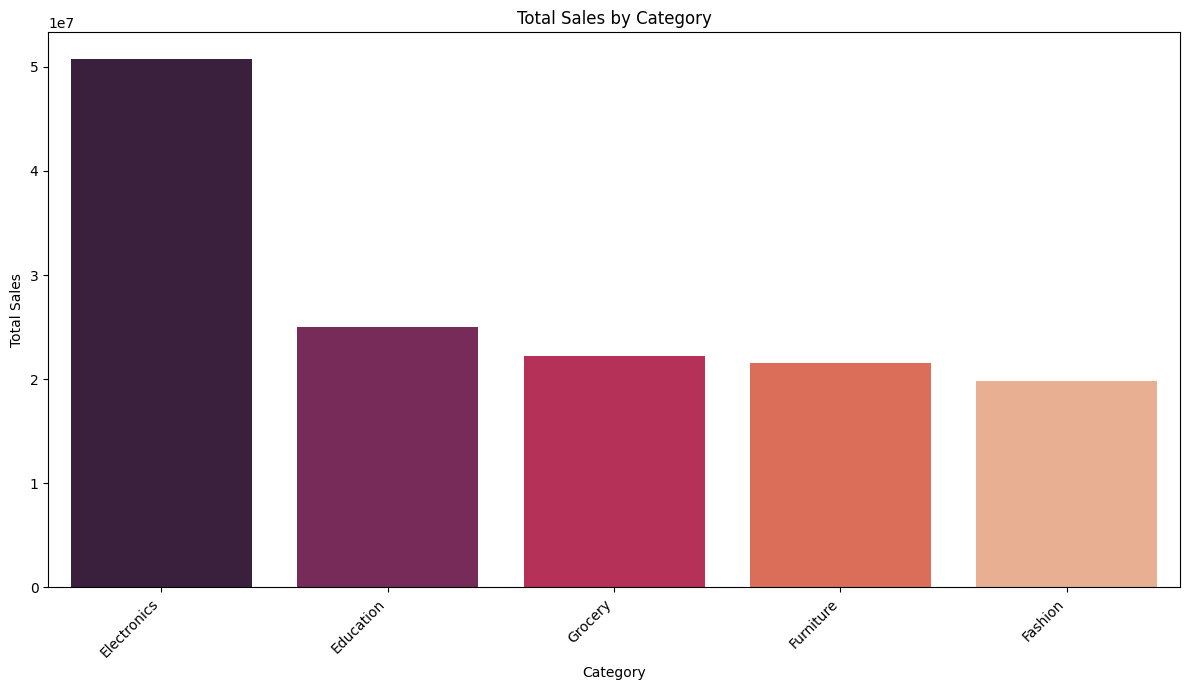

In [21]:
# Sales by Category
sales_by_category = df.groupby('Category')['Total_Sales'].sum().reset_index().sort_values(by='Total_Sales', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(data=sales_by_category, x='Category', y='Total_Sales', palette='rocket')
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/tmp/ipykernel_387/830071079.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sales_by_product, x='Product', y='Total_Sales', palette='viridis')


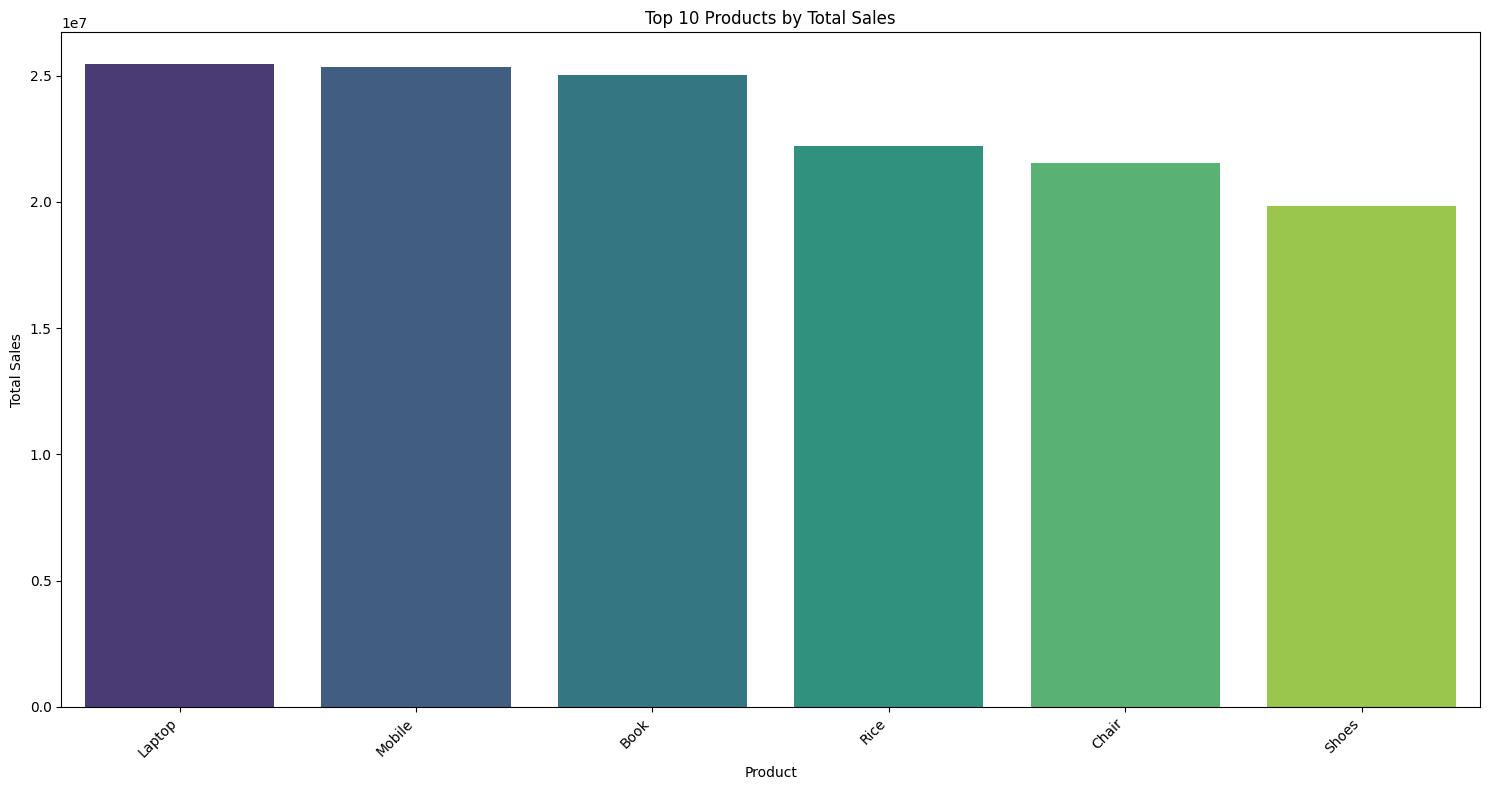

In [22]:
# Sales by Product (Top 10)
sales_by_product = df.groupby('Product')['Total_Sales'].sum().reset_index().sort_values(by='Total_Sales', ascending=False).head(10)

plt.figure(figsize=(15, 8))
sns.barplot(data=sales_by_product, x='Product', y='Total_Sales', palette='viridis')
plt.title('Top 10 Products by Total Sales')
plt.xlabel('Product')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Define Core KPIs

Based on our data and initial analysis, here are some core Key Performance Indicators (KPIs) that can be tracked for this business:

1.  **Total Sales Revenue**: The overall sum of `Total_Sales`. This is a primary indicator of business growth and financial health.
2.  **Average Order Value (AOV)**: `Total_Sales` / `Number of Orders`. This helps understand customer spending habits per transaction.
3.  **Sales by Category/Product**: Total sales generated by each product category and individual product. This identifies top-performing items and areas for focus.
4.  **Sales by City**: Total sales attributed to different cities. This highlights geographical strengths and potential areas for market expansion.
5.  **Number of Unique Customers**: Total distinct `Customer_ID`s. This indicates customer base growth.
6.  **Customer Repeat Rate / Retention**: (Number of repeat customers / Total unique customers) * 100. (Requires more historical data for accurate calculation).
7.  **Sales Growth (Month-over-Month/Year-over-Year)**: Percentage change in total sales over defined periods. (Requires more historical data).

Let's calculate and display some of these core KPIs that can be derived from the current dataset.

In [26]:
# 1. Total Sales Revenue
total_sales_revenue = df['Total_Sales'].sum()
print(f"Total Sales Revenue: {total_sales_revenue:,.2f}")

# 2. Average Order Value (AOV)
average_order_value = df['Total_Sales'].sum() / df['Order_ID'].nunique()
print(f"Average Order Value (AOV): {average_order_value:,.2f}")

# 3. Number of Unique Orders
unique_orders = df['Order_ID'].nunique()
print(f"Number of Unique Orders: {unique_orders}")

# 4. Number of Unique Customers
unique_customers = df['Customer_ID'].nunique()
print(f"Number of Unique Customers: {unique_customers}")


Total Sales Revenue: 139,399,439.65
Average Order Value (AOV): 140,523.63
Number of Unique Orders: 992
Number of Unique Customers: 947
